# Introduction

A group of UBC computer science students, named The Pacific Laboratory for Artificial Intelligence (PLAI), are conducting research on player actions in their own MineCraft server, PLAIcraft. This is being done with hopes of developing an advanced AI tool, also known as embodied AI, to implement in the video game. Additionally, supporting the server requires adequate information about the amount and type of players for recruitment efforts. As such, data on players and their gameplay is being collected through this MineCraft server.  


## Data Description (subtitle tbd)

In [1]:
library(tidyverse)
library(tidymodels)
library(themis)
set.seed(1234)
players <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/sessions.csv")

sessions_compressed <- sessions |>
    select(hashedEmail) |>
    group_by(hashedEmail) |>
    summarize(session_count = n())

combined_data <- players |>
    inner_join(sessions_compressed)

head(combined_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

experience,subscribe,hashedEmail,played_hours,name,gender,Age,session_count
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,27
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,3
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,1
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,1
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21,1


## Summary statistics

We will now acquire relevant summary statistiscs for our analysis from the combined dataset created above. We would like to look at the median and mean of player age, as well as the mean # of session per player.

In [2]:
# summary of player ages
summary_age <- players |>
    mutate(avg_age = mean(Age, na.rm = TRUE), 
            med_age = median(Age, na.rm = TRUE)) |>
    select(avg_age, med_age) |>
    slice(1) |>
    mutate(avg_age = round(avg_age, 2))
summary_age

avg_age,med_age
<dbl>,<dbl>
21.14,19


The average age is roughly 21 years old while the median is 19. This suggests that we have majority individuals in their teens and twenties participating.

In [3]:
# summary of player sessions
summary_session <- combined_data |>
        mutate(avg_session = mean(session_count), na.rm = TRUE) |>
        select(avg_session) |>
        slice(1) |>
        mutate(avg_session = round(avg_session, 2))
summary_session

avg_session
<dbl>
12.28


The average was roughly 12 sessions per player.

# Methods

## Determining the method for data analysis 

In [4]:
minecraft_clean<- combined_data|> 
drop_na(Age, session_count)

The data was cleaned to drop any NA values for the following steps. This makes the data have an equal amount of predictors for the bind_cols function that will be used to analyze the strength of our model. 

In [5]:
subscribe_count<- minecraft_clean|> 
count(subscribe)

subscribe_count

subscribe,n
<lgl>,<int>
FALSE,32
TRUE,91


**Table 1.** The above code checks the balance of the data. From the table we can see that the TRUE label is overrepresented in the data set (3:1 ratio) and therefore there is an inbalance in the data. These results indicate that we should rebalance the data for more accurate results after checking for linearity between our variables. 

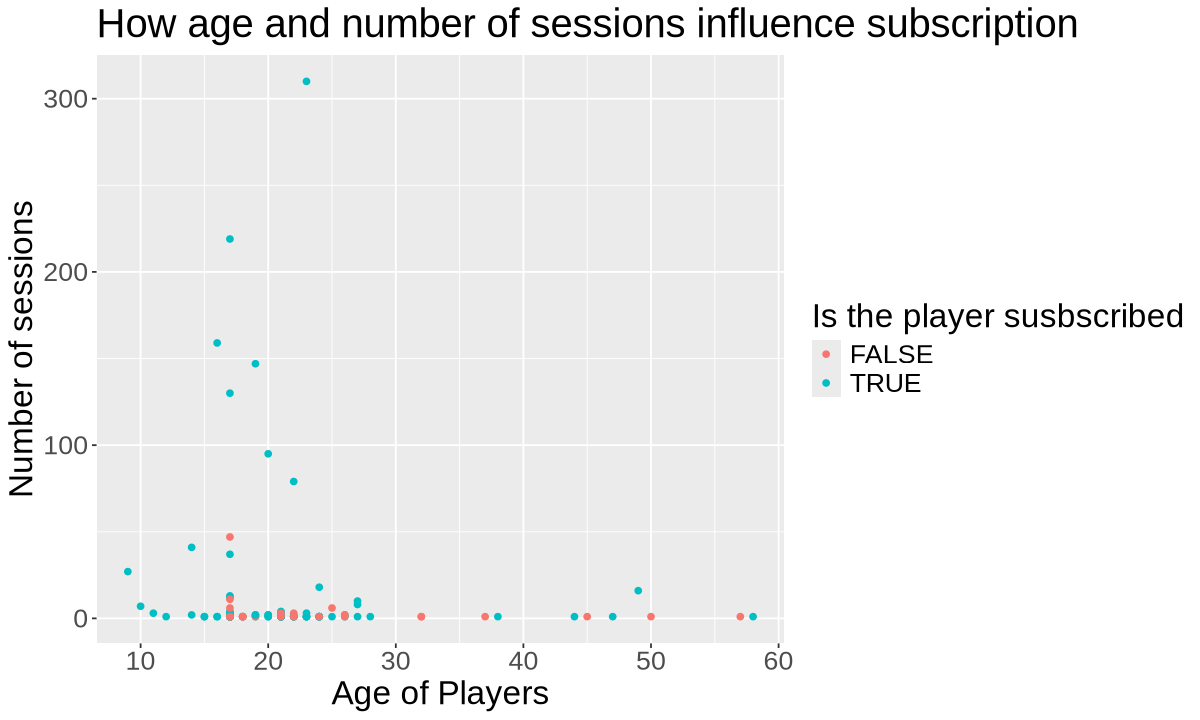

In [6]:
options(repr.plot.width=10, repr.plot.height=6)

plot_of_age_vs_subscription<- ggplot(minecraft_clean, aes(x = Age, y = session_count))+
geom_point(aes(colour = subscribe))+ 
xlab("Age of Players")+ 
ylab("Number of sessions")+ 
ggtitle("How age and number of sessions influence subscription")+
labs(colour= "Is the player susbscribed")+
theme(text = element_text(size = 20))

plot_of_age_vs_subscription

**Figure 1.** To determine which predictive model to use in our analysis we visualized our variables to see if there was a linear relationship. This data was then plotted using age on the y-axis, session_count on the y-axis, and colouring the data points based on subscription status. The plot shows that there is not a linear relationship between the two variables and therefore using a linear regression model would not improve the analysis. Therefore, Figure 1 indicates that we should use K-NN classification to understand the relationship between age and session_count. 

## Renaming the Subscribe observations and balancing the data 

In [7]:
minecraft_clean <- minecraft_clean |>
  mutate(subscribe = factor(subscribe))




The above code changes the outcome variable to a factor. This is important because the K-NN classification models require that the output variable is a factor with clearly defined labels. The original output variables (TRUE and FALSE) are logical and therefore are not able to be used in the classification model unless changed.

## Splitting the data for training and analysis 

In [8]:
minecraft_split<- initial_split(minecraft_clean, prop = 0.75, strata = subscribe)
minecraft_training<- training(minecraft_split) 
minecraft_testing<- testing(minecraft_split)

## Making a recipe

In [9]:
minecraft_vfold<- vfold_cv(minecraft_training, v= 5, strata = subscribe)

minecraft_recipe<- recipe(subscribe ~ Age + session_count, data = minecraft_training)|> 
step_scale(Age, session_count)|> 
step_center(Age, session_count)|> 
step_upsample(subscribe)

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: Age and session_count

• Centering for: Age and session_count

• Up-sampling based on: subscribe



## Creating the K-NN classifier 

In [10]:
minecraft_knn_spec<- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|> 
set_engine("kknn") |> 
set_mode("classification")
minecraft_knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [20]:
k_vals<- tibble(neighbors = seq(from = 1, to = 45, by=2))

knn_k_specification_results<- workflow()|> 
add_recipe(minecraft_recipe)|> 
add_model(minecraft_knn_spec)|>
tune_grid(resamples = minecraft_vfold, grid = k_vals)|> 
collect_metrics()


head(knn_k_specification_results)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5965256,5,0.01934357,Preprocessor1_Model01
1,roc_auc,binary,0.6089560,5,0.02295849,Preprocessor1_Model01
3,accuracy,binary,0.5315445,5,0.02463136,Preprocessor1_Model02
3,roc_auc,binary,0.6392857,5,0.02744174,Preprocessor1_Model02
5,accuracy,binary,0.4888545,5,0.02588613,Preprocessor1_Model03
5,roc_auc,binary,0.6404396,5,0.03219405,Preprocessor1_Model03


**Table 2.** The table above shows the K values tested, their respective accuracies and how well the model ranks the positive and negative cases. The mean collumn corresponds to mean across the 5 fold cross validation and then the standard error is displayed as well. This data can be graphed as seen below to help identify the best K value for the model. 

## Graph of the K values 

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


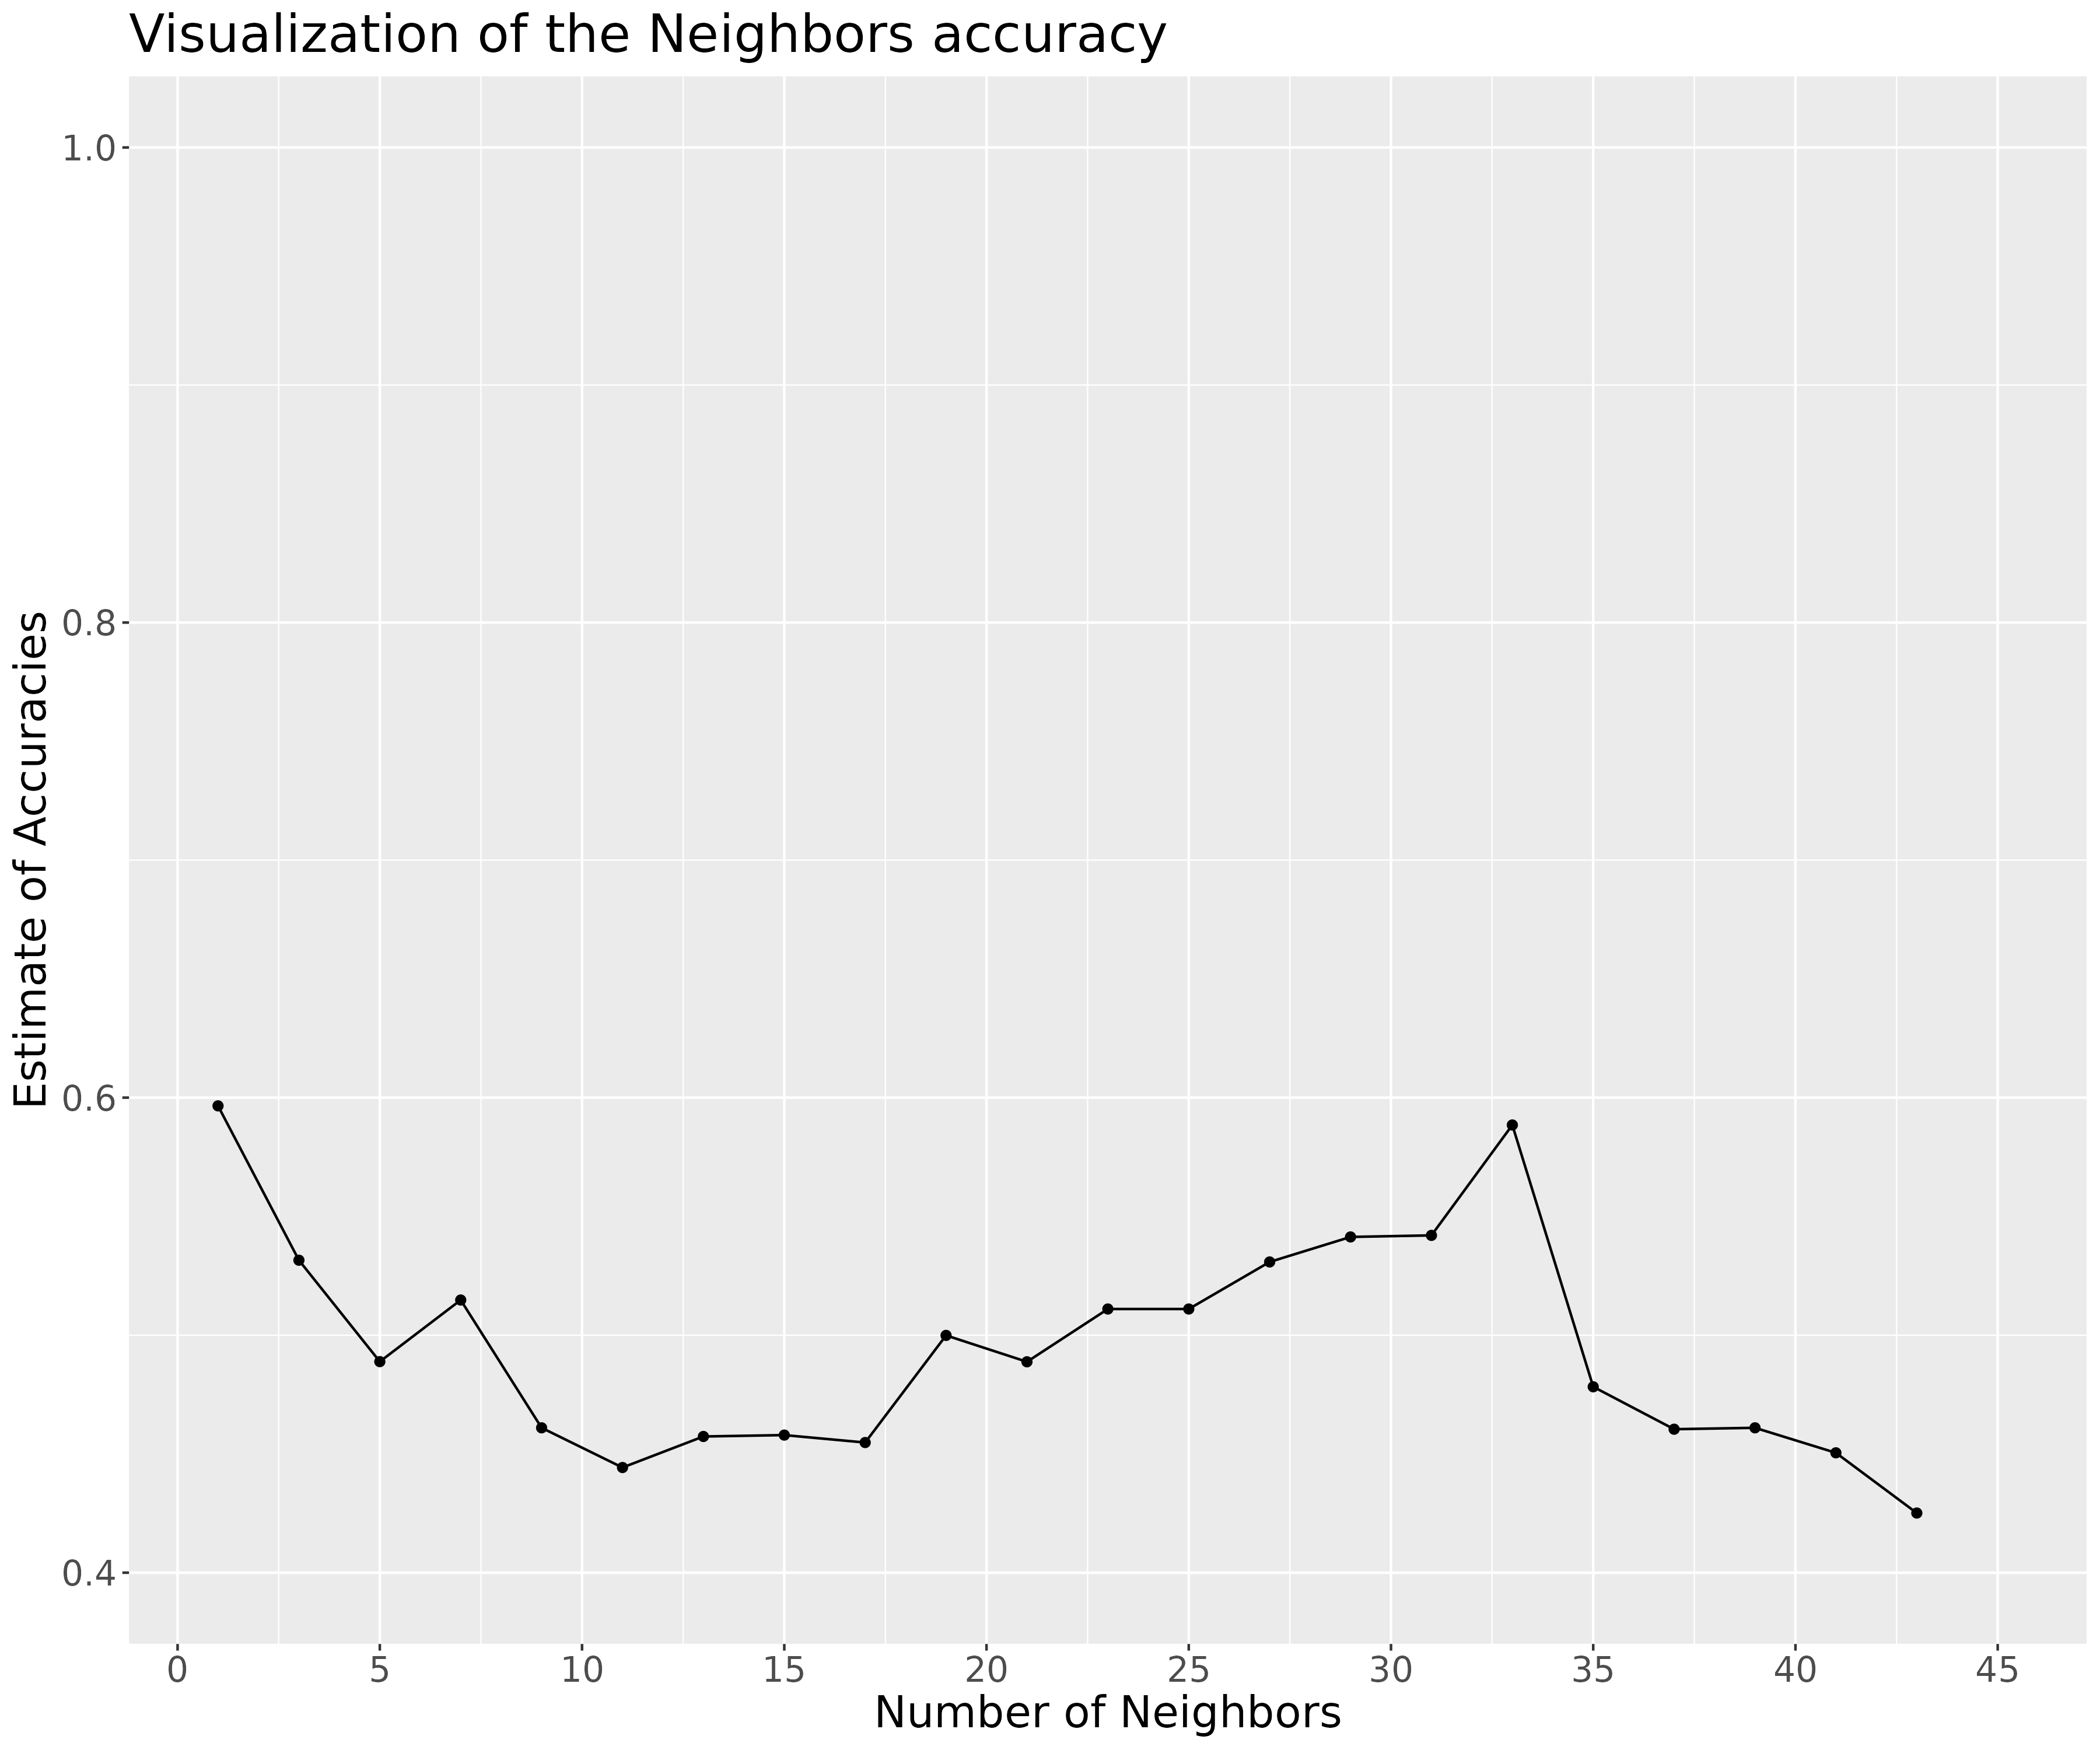

In [21]:
minecraft_accuracy<- knn_k_specification_results|> 
filter(.metric == "accuracy")

plot_of_k_values<- ggplot(minecraft_accuracy, aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbors")+ 
ylab("Estimate of Accuracies")+ 
ggtitle("Visualization of the Neighbors accuracy")+
scale_x_continuous(breaks = seq(0, 55, by = 5)) +  
       scale_y_continuous(limits = c(0.4, 1.0))+
theme(text = element_text(size = 18))

ggsave("plot_of_k_values.png", plot = plot_of_k_values, width = 12, height = 10, dpi = 300)

IRdisplay::display_png(file = "plot_of_k_values.png")


**Figure 2.** The figure above graphs the number of K values versus the estimate of accuracy. From the graph it is observed that K = 1 has the highest accuracy and therefore is the best K value to use in the K-NN classification model. 

## Using the Model on Testing data 

In [22]:
minecraft_recipe_final<- recipe(subscribe ~ Age + session_count, data = minecraft_training)

minecraft_knn_spec_k<- nearest_neighbor(weight_func = "rectangular", neighbors = 1)|> 
set_engine("kknn")|> 
set_mode("classification")

minecraft_fit<- workflow()|> 
add_recipe(minecraft_recipe_final)|> 
add_model(minecraft_knn_spec_k)|> 
fit(data = minecraft_training)

minecraft_predictions<- predict(minecraft_fit, new_data = minecraft_testing) |> 
bind_cols(minecraft_testing)

minecraft_metrics<- minecraft_predictions|> 
metrics(truth = subscribe, estimate = .pred_class)

minecraft_metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.3548387
kap,binary,-0.2704918


In [25]:
minecraft_conf_mat<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)

minecraft_conf_mat

          Truth
Prediction FALSE TRUE
     FALSE     2   14
     TRUE      6    9

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


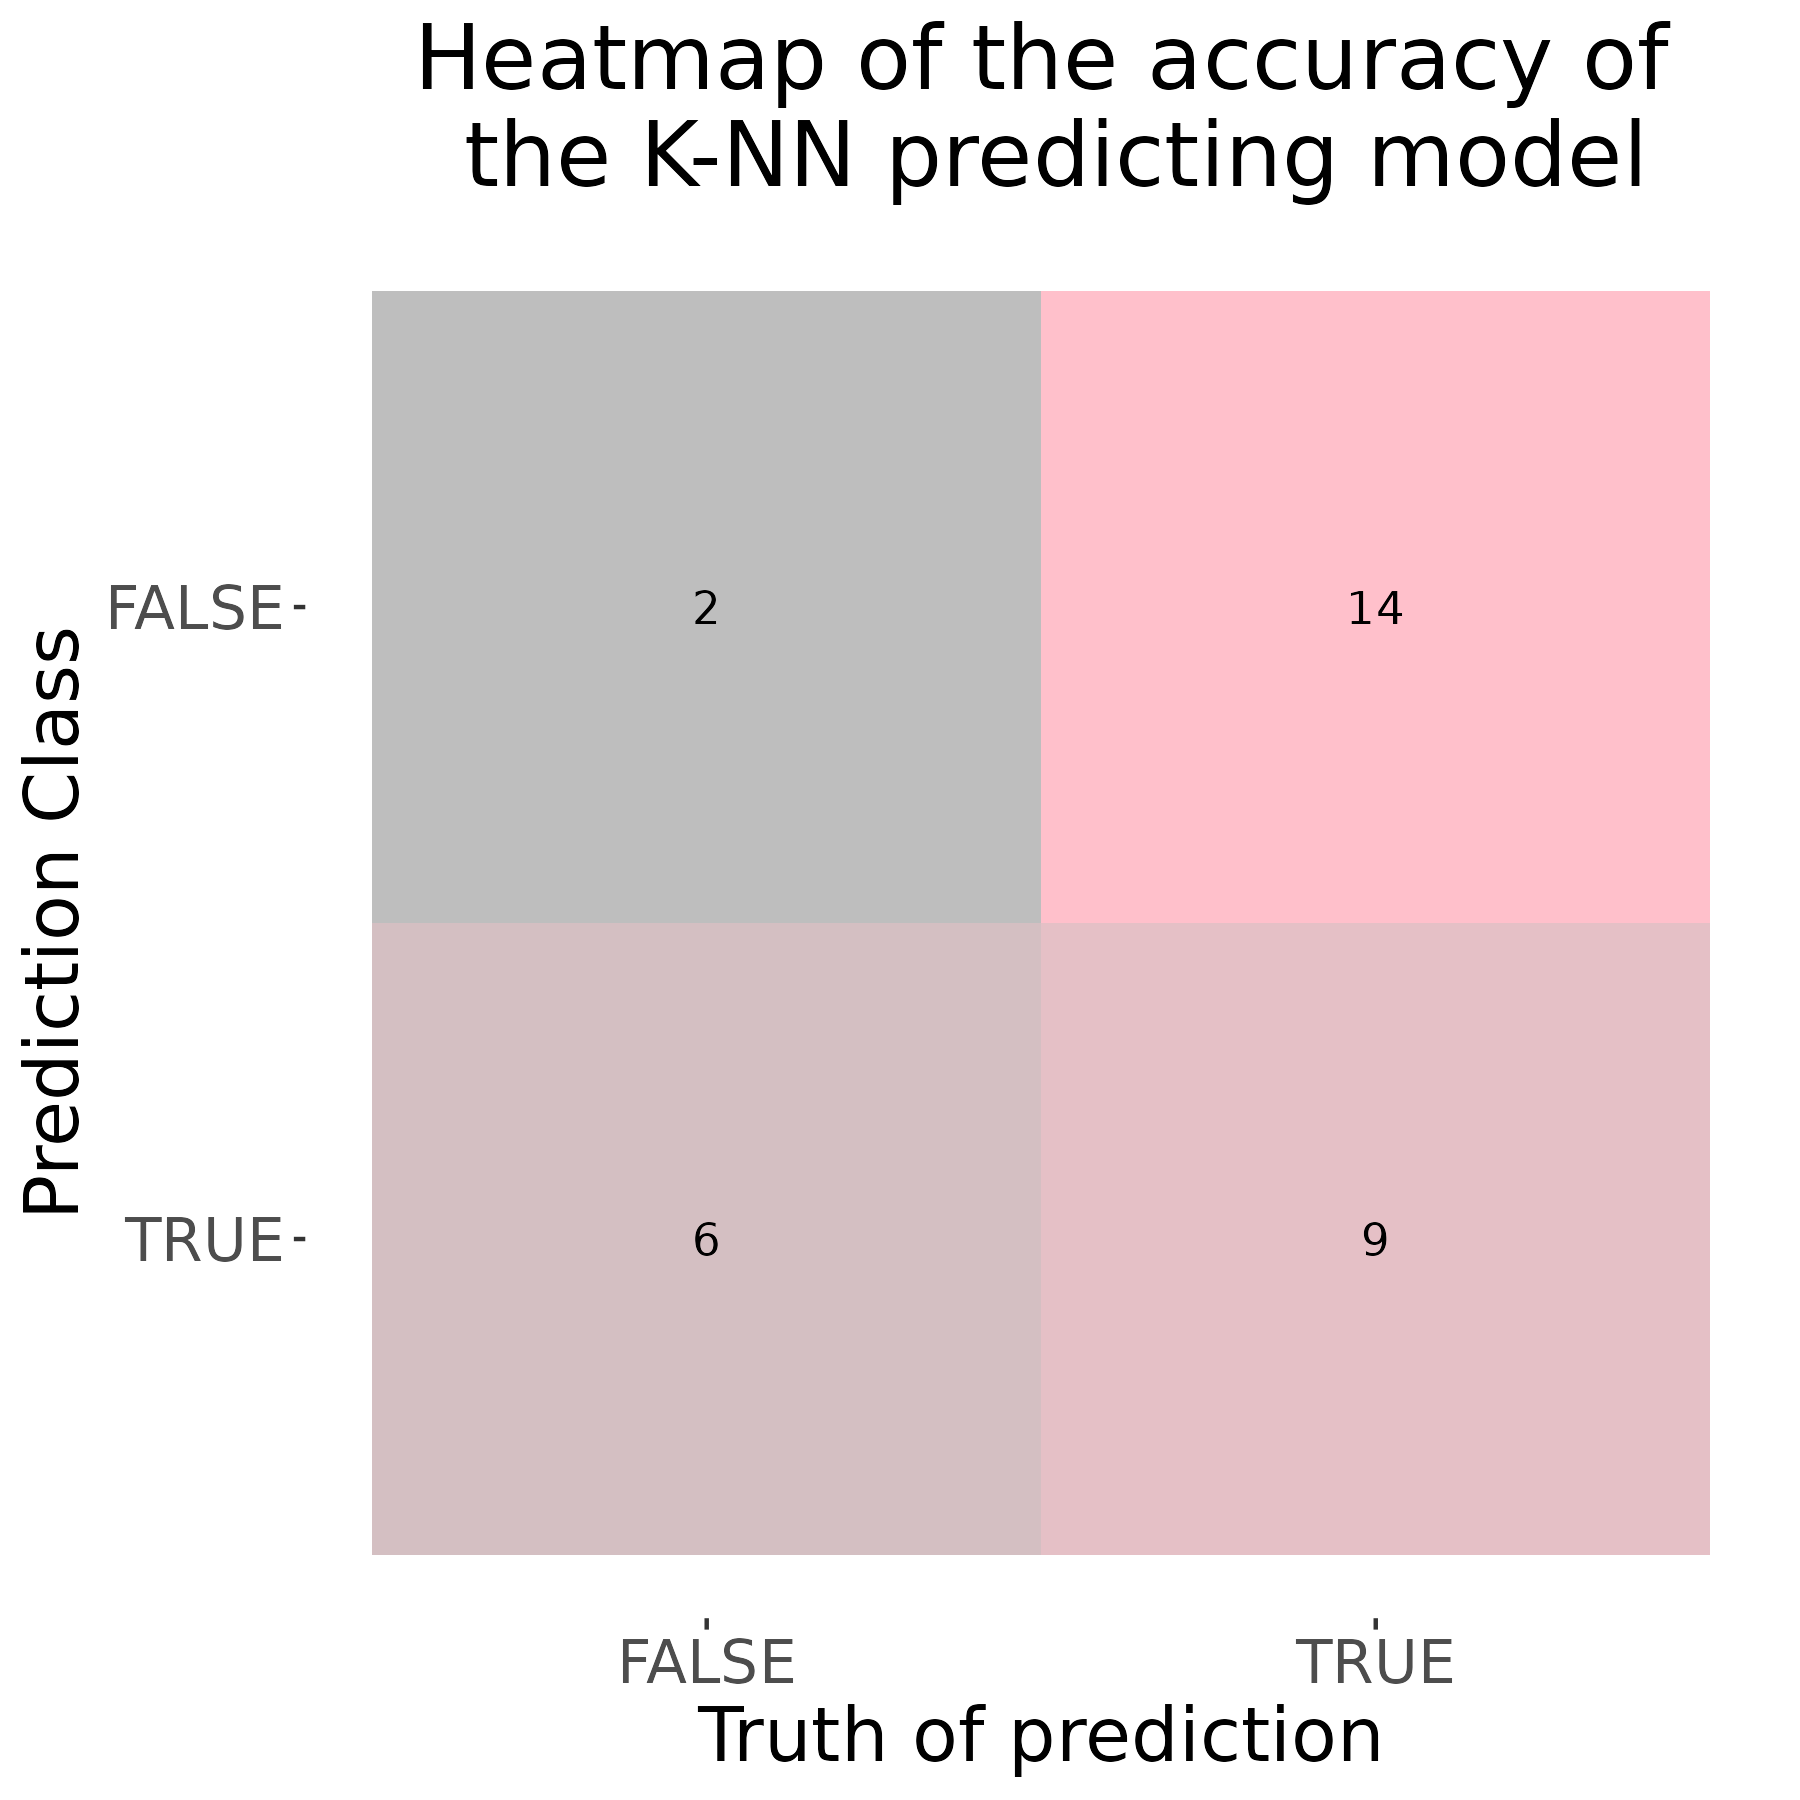

In [15]:
minecraft_conf_mat_heatmap<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)|> 
autoplot(type = "heatmap")+ 
scale_fill_gradient(low = "grey", high = "pink")+ 
labs(x = "Truth of prediction", y= "Prediction Class", title = "Heatmap of the accuracy of\n the K-NN predicting model")+ 
theme(text = element_text(size = 18), 
    plot.title = element_text(hjust = 0.5))


ggsave("minecraft_conf_mat_heatmap.png", plot = minecraft_conf_mat_heatmap, width = 6, height = 6, dpi = 300)


IRdisplay::display_png(file = "minecraft_conf_mat_heatmap.png")

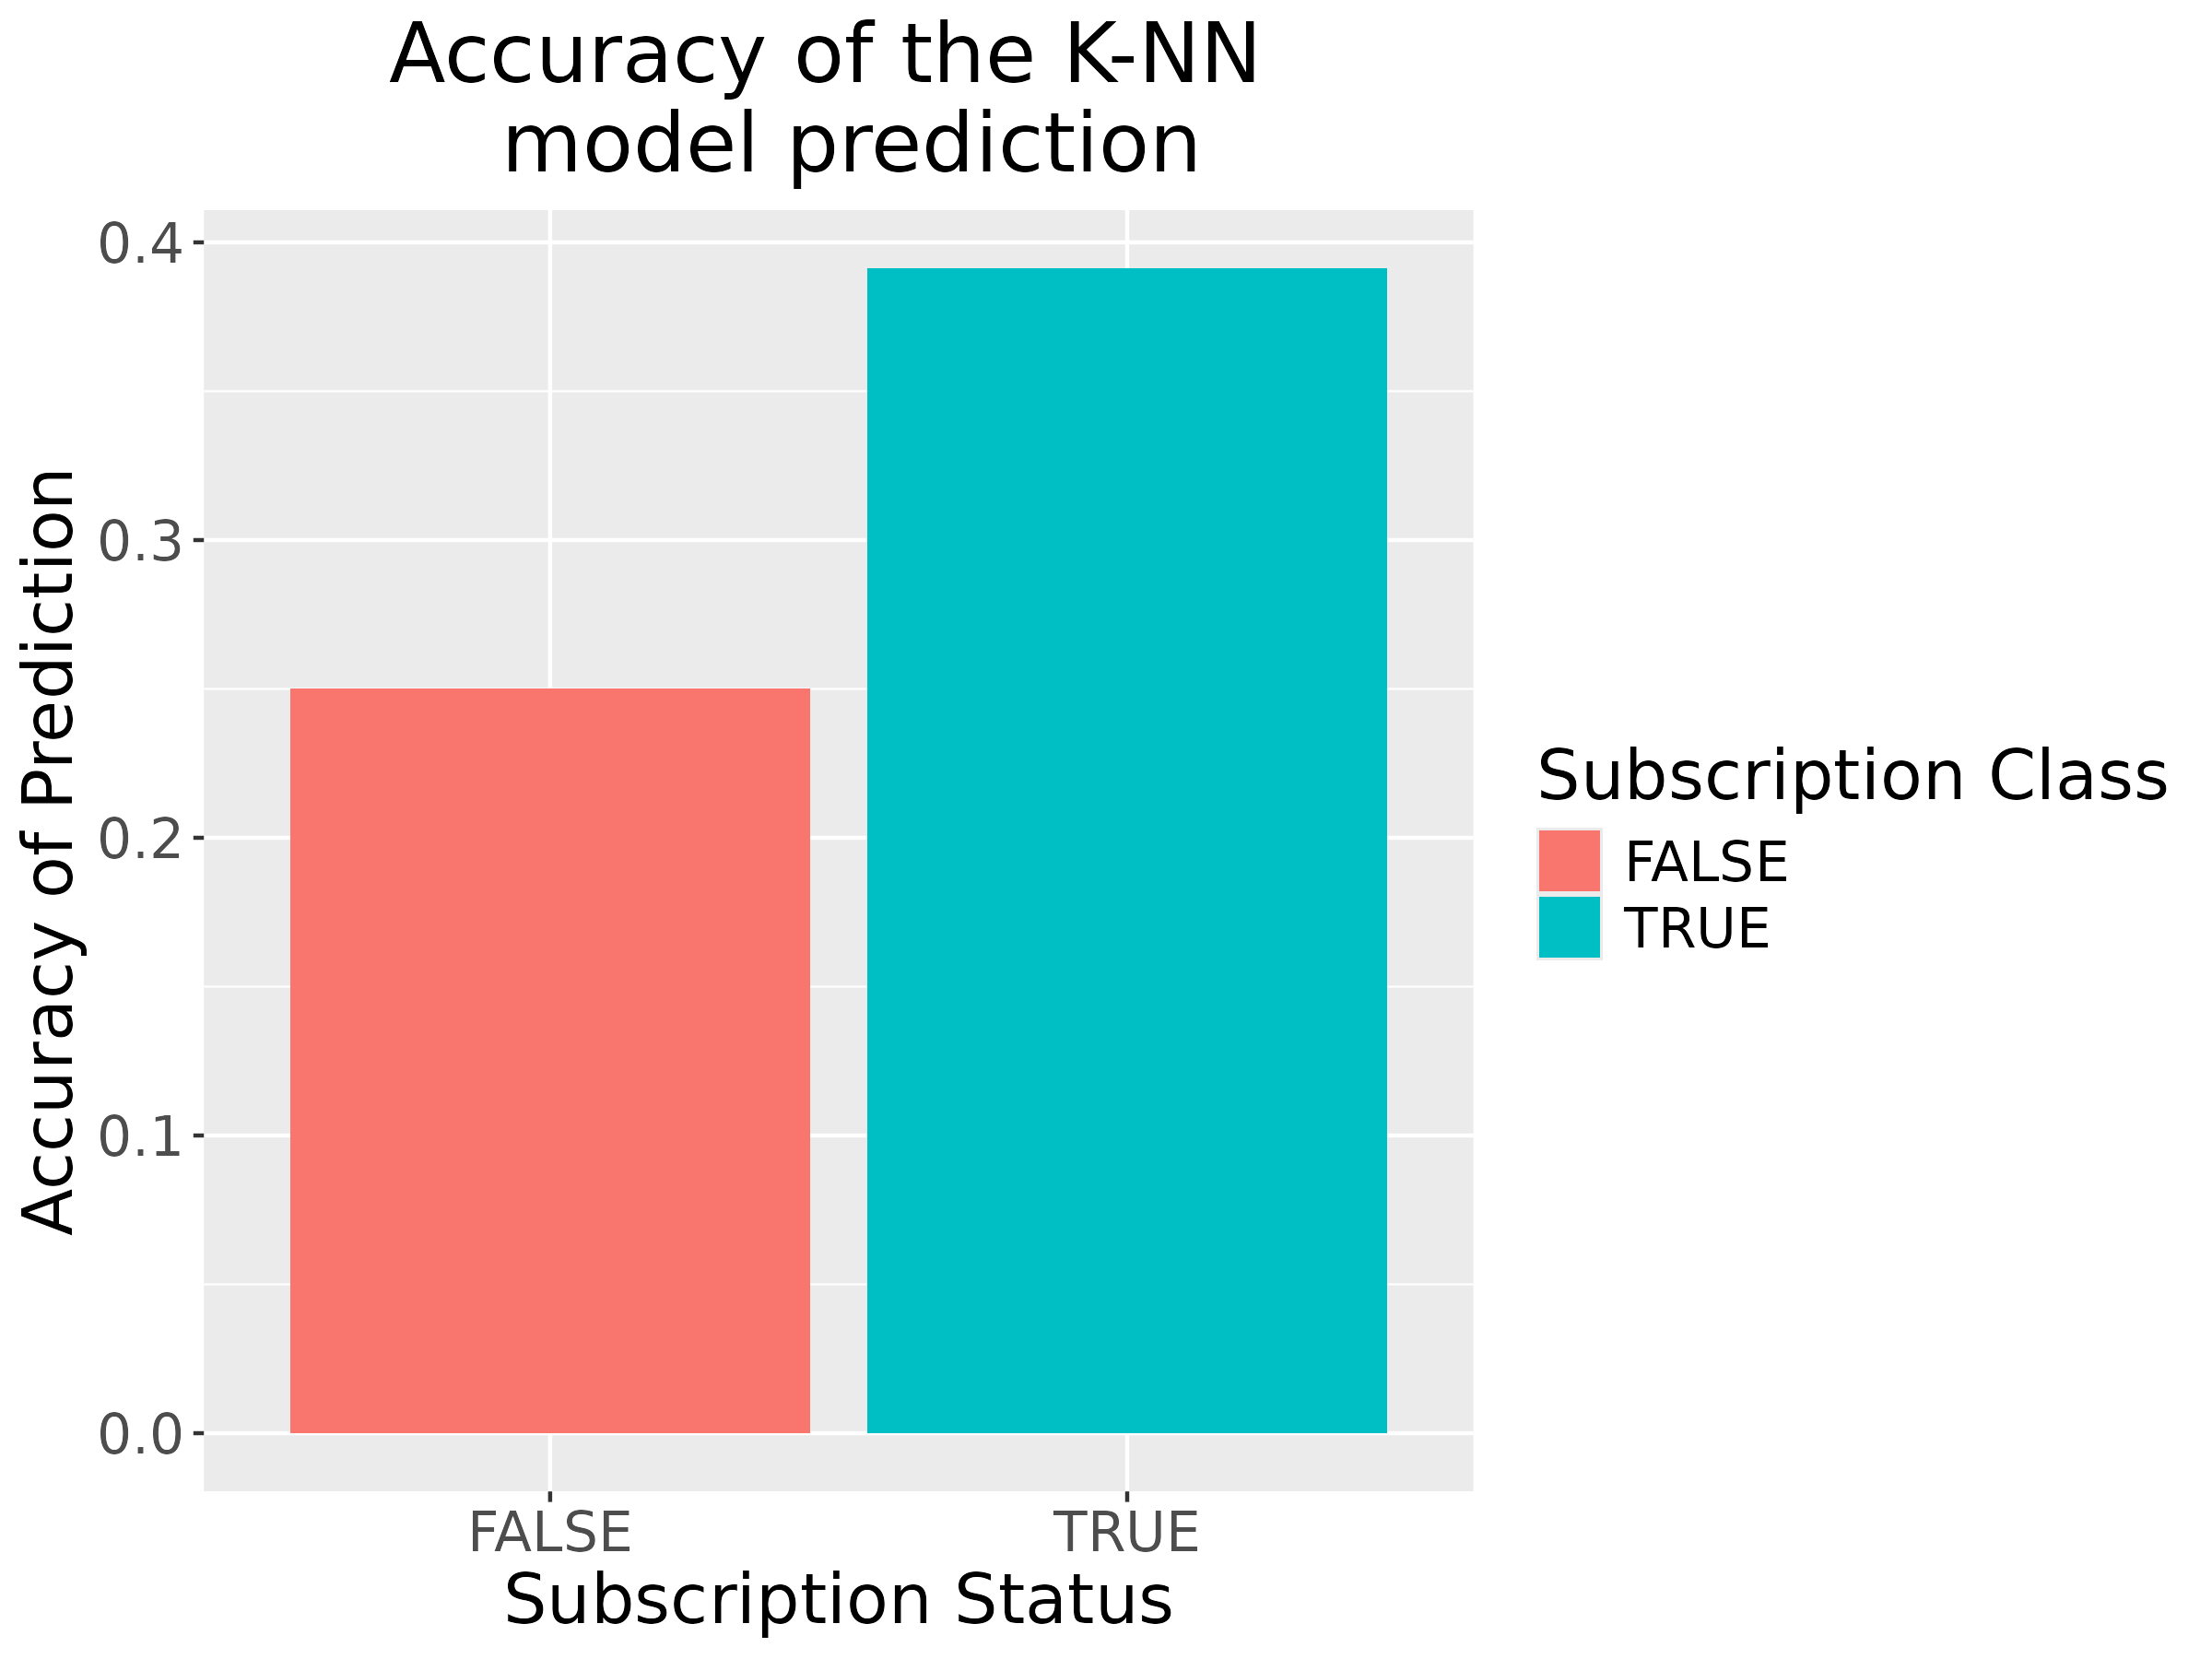

In [16]:
knn_conf_analysis<- minecraft_predictions |>
  group_by(subscribe) |>
  accuracy(truth = subscribe, estimate = .pred_class)

graph_of_knn_prediction<- knn_conf_analysis|>
ggplot(aes(x = subscribe, y = .estimate, fill = subscribe)) +
geom_col()+ 
xlab("Subscription Status")+ 
ylab("Accuracy of Prediction")+
ggtitle("Accuracy of the K-NN \n model prediction")+ 
labs(fill = "Subscription Class")+
theme(text = element_text(size = 18),
     plot.title = element_text(hjust = 0.5))

ggsave("graph_of_knn_prediction.png", plot = graph_of_knn_prediction, width = 8, height = 6, dpi = 300)


IRdisplay::display_png(file = "graph_of_knn_prediction.png")
